<a href="https://colab.research.google.com/github/divyanshu-png/VOID/blob/main/LangGraph_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[Reference Video for Learning LangGraph
](https://youtu.be/jGg_1h0qzaM?si=6Jfc-sC8FtDt3Oee)

In [ ]:
#@title TYPE ANNOTATIONS
!pip3 install typing


Type annotations are a way to explicitly declare what data type a variable, function parameter, or return value should be. .

@Typed DICTIONARIES
this is a type od dictionary that ensures type safety - we explicitly define what the data structures contains, reducing runtime errors.
Makes debugging easier and makes code readable and understandable.

In [ ]:
##Typed Dictionaries
from typing import TypedDict
class Movie(TypedDict):
    name: str
    year: int
movie6 = Movie(name= "Avengers Doomsday", year=2026)
movie5 = Movie(name="Avengers Endgame", year=2019)
movie4= Movie(name="Avengers: Age of Ultron", year=2015)

In [ ]:
movie4 #gets printed as a regular dictionary

{'name': 'Avengers: Age of Ultron', 'year': 2015}

@union
ts helps in specifying that a variable can be any of (one or more) datatype:

Here in the example below: we have set the datatype of the variable to either int or float. This provides type safety as it can provide hints to help catch incorrect usage

In [ ]:
from typing import Union
def sqaure(x: Union[int,float])-> float:
    return x*x
x= 5
x= 23.34

x= "I am string"

@optional ;

An Optional type explicitly indicates that a value can either be a specific data type or it can be empty (None). In modern development, Optional[X] is simply a specialized shorthand variant of a Union type (X | None).

In [ ]:
from typing import Optional

def nice_message(name : Optional[str]) -> None:
    if name is None  :
        print("hey random person! ")
    else:
        print(f'Hi there {name}')

nice_message("Divyanshu")

Hi there Divyanshu


In [ ]:
nice_message(None);

hey random person! 


@Any

means that the value/ variable can be any datatype


In [ ]:
from typing import Any
def print_value(x: Any):
    print(x, ":", type(x))

print_value("Hello my name is Divyanshu")

Hello my name is Divyanshu : <class 'str'>


In [ ]:
print_value(783035)

783035 : <class 'int'>


#A) Elements in LangGraph

##State
A state is a shared Data structure taht holds the current information or contextif the entire application.
In simple terms, it is like the application's memory, keeping track of the variables and data that nodes can access and modify as they execute.

##Nodes
Nodes are individual functions or operations that perform specific tasks within the graph.
Each node recieves an input processes it and produces an output or an updated State.

##Graphs
Graph is an overarching structure that maps out how different tasks(nodes) are connected and executed.
It visually represents the workflow, showing the sequence and conditional paths between various operations.

##Edges
Edges are the connections between the nodes that determine the flow of the execution. They tell us which node should be executed next after the current one completes its task.

##Conditional edge
Specialized connnection that decide the next node to be executed based on the specific consitions or logic applied to the current State.

##Start Node / Start Point
A virtual entry point in the LangGraph, marking where the workflow begins. It doesn't perform any operations itself but serves as the designated starting point for the graph's execution.

##End Node/ End point
Signifies the conclusion of the workflow in LangGraph. Upon reaching the end-point the graph's execution stops, indicating that all intended processes have been completed.

# Tools
Tools are specialzed functions or utilities that "nodes" can utilize to perform specific tasks such as fetching the data from an API.
They enhance the capabilities of nodes by providing the additional functionalitites that are needed by the Node.

### Is there a middle man between the tool and the node ??
## Toolnode
A tool node is just a special kind of ndoe whose main job is to run a tool.
It connects the tool's output back into the state, so ohter nodes cna use that information.


#StateGrpah
it is a class in LangGraph used to build and compile the grpah Strucutre. It manages the nodes, edges, and the overall state, ensuring that the workflow operates in a unified way and that data flows correctly between components.
Just like the blueprint of constructing a house outlines the design and connections within a building, a StateGraph is used to structure the flow of the workflow or agent.


##Runnable
A standardized executable component that performs a specific task within an AI workflow.
It serves as a fundamental building block, allowing for us to create modular systems.





#B) Types of messages in langGraph:

##i) Human message
represnts the input from a user
##ii) System message
Used to provide instruction or context to the model
##iii) AI message
Represnts responses generated by AI models
##iv) Tool message
Similar to function message but specific to tool usage
##v) Function message
Represents the result of a function call




In [ ]:
# creating a graph : the hello world graph : a start, node and end graph

!pip install langgraph

In [ ]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph


In [ ]:
#now we create an Agent State-  shared data strucutre that keeps track of the information as your application runs

class AgentState(TypedDict) : # our state schema
    message:str

#Node : how do we define a node : the input and output type of a node that is a function need to be a state

def greetingNode(state: AgentState) -> AgentState:
    ''' Simple node that adds a greeting message to the start of a state'''
    state['message'] = "Hey! My name is grettingNode! " + state["message"]
    return state

In [ ]:
graph = StateGraph(AgentState)
graph.add_node("Greeter", greetingNode) # the two parameters that will be neede by the add function to add a node to the graph is the name of the graph that you decide and will be referenced later,  and the function the node performs

#Adding the entry point and end point
graph.set_entry_point("Greeter")
graph.set_finish_point("Greeter")

app = graph.compile()
#just because the graph compiled without error doesn't mean that it will succesfully run

In [ ]:
result = app.invoke({"message": "Hello my name is Divyanshu"})
result["message"]

'Hey! My name is grettingNode! Hello my name is Divyanshu'

In [ ]:
# a practice graph:  A personalized Compliment agent :

# agent state: a typed dictionary that defines the variables of the state
class AgentState2(TypedDict):
    message: str

# function the node will perform
def advancedGreetNode(state: AgentState2) -> AgentState2:
    state["message"] = state["message"] + ", you are doing an amazing Job!"
    #updates the current state to add a message to the end of an existing message
    return state

graph = StateGraph(state_schema= AgentState2)
#TO CREATE A GRAPH WE NEED TO SPECIFY THE state_schema: The schema class that defines the state.

graph.add_node("complimenter",advancedGreetNode)
graph.set_entry_point("complimenter")
graph.set_finish_point("complimenter")

app = graph.compile()
result = app.invoke({"message" : "Bob"})
result["message"]

'Bob, you are doing an amazing Job!'

In [ ]:
#Second Graph : Multiple Inputs Graph

#Im sure well have to make the state that has multiple variables rather than the single typed dict were making

from typing import TypedDict, List
from langgraph.graph import StateGraph


class AgentState(TypedDict):
    values: List[int]
    name: str
    result : str


In [ ]:
def process_values(state: AgentState) -> AgentState:
    '''this function handles acts as the function of the node and handles multiple different inputs '''
    print(state)

    state["result"] = f"Hi there {state["name"]}, your sum is {sum(state["values"])}"
    print(state)
    return state


graph = StateGraph(AgentState)
graph.add_node("Sum-er", process_values)

graph.set_entry_point("Sum-er")
graph.set_finish_point("Sum-er")

app= graph.compile()


In [ ]:
answers = app.invoke({"values":[1,2,3,4,5] , "name":"Divyanshu"})
# the result has been intialised to None and thus can be assigned by the function performed by the node. If otherwise the node function needed the value of result to omit some other variable then this should have been a problem

print(answers["result"])

{'values': [1, 2, 3, 4, 5], 'name': 'Divyanshu'}
{'values': [1, 2, 3, 4, 5], 'name': 'Divyanshu', 'result': 'Hi there Divyanshu, your sum is 15'}
Hi there Divyanshu, your sum is 15


In [ ]:
#Second exercise :

from typing import TypedDict ,List
from langgraph.graph import StateGraph

class state(TypedDict):
    name :str
    values: List[int]
    operator :str
    result : str

def node_func(state) -> state:
    if state["operator"] =="*":
        res = 1
        for num in state["values"] :
            res *= num
        state["result"] = f"Hi {state["name"]}, the result is {res}"
        return state
    else:
        res= 0
        for num in state["values"]:
            res+=num
        state["result"] = f"Hi {state["name"]}, the result is {res}"
        return state


graph = StateGraph(state)
graph.add_node("func", node_func)
graph.set_entry_point("func")
graph.set_finish_point("func")

app = graph.compile()
answer = app.invoke({"name":"Divyanshu", "values": [1,2,3,4,5,6], "operator": "*"})
print(answer["result"])

Hi Divyanshu, the result is 720


#Sequential Graph

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [ ]:
class AgentState(TypedDict):
    name: str
    age : int
    final: str

def first_node_op(state:AgentState) -> AgentState:
    """this is the function for the first node of our sequence"""
    state["final"] = f"Hi {state["name"]}, you are {state["age"]} years old!"
    return state

def second_node_op(state :AgentState) -> AgentState :
    """this is the function for the second node of our sequence"""
    state["final"] += " You are doing an amazing job"
    return state

graph = StateGraph(AgentState)
graph.add_node("firstNode", first_node_op)
graph.add_node("secondNode", second_node_op)

graph.add_edge("firstNode", "secondNode")

graph.set_entry_point("firstNode")
graph.set_finish_point("secondNode")


app = graph.compile()
results = app.invoke({ "name":"Divyanshu", "age": 20})
print(results["final"])

Hi Divyanshu, you are 20 years old! You are doing an amazing job


In [ ]:
#Excercising the mutlinode graph

from typing import TypedDict, List
from langgraph.graph import StateGraph

class agentState(TypedDict):
    name:str
    age:int
    skills :List[str]
    message : str

def first_node_op(state :agentState ) -> agentState :
    ''' This defines the operation that we need to perform in the first node. The planned function is to alter the message and add a greeting with the name of the user '''
    state["message"] = f"Hello {state["name"]} , welcome to the system!"
    return state

def second_node_op(state :agentState)-> agentState :
    '''this defined the operation for the second node. We are trying to add the users age description via this node in the message'''
    state["message"] += f" You are {state["age"]} years old!"
    return state
def third_node_op(state : agentState) -> agentState :
    '''this defines the operation for the third node that will add a string to the existing message defining the user's skills'''
    mess = " You have the following skills listed in the directory: "
    for skill in state["skills"]:
        mess += skill+", "
    state["message"] += mess

    return state

graph = StateGraph(agentState)
graph.add_node("firstNode", first_node_op)
graph.add_node("secondNode", second_node_op)
graph.add_node("thirdNode", third_node_op)

graph.add_edge('firstNode', 'secondNode')
graph.add_edge('secondNode', "thirdNode")

graph.set_entry_point("firstNode")
graph.set_finish_point("thirdNode")

app = graph.compile()
results = app.invoke( { "name": "Divyanshu", "age":20, "skills" : ["Python","LangGraph", "DSA", "JavaScript", "React"] } )

print(results["message"])


Hello Divyanshu , welcome to the system! You are 20 years old! You have the following skills listed in the directory: Python, LangGraph, DSA, JavaScript, React, 


#Conditional Graph

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

In [ ]:
class agentState(TypedDict):
    number1: int
    number2 :int
    operation :str
    result :int

def first_node_op(state :agentState) -> agentState:
    '''The first node that runs if the operation is addition'''
    state["result"] = state ["number1"]+state["number2"]
    return state

def second_node_op(state : agentState)-> agentState:
    '''The second node that runs if the operation is multiplication'''
    state["result"] = state["number1"]*state["number2"]
    return state

def decide_next_node(state: agentState)-> agentState:
    '''This node decides to which node the state will flow based on some condition'''
    if state["operation"] == "+":
        return "addition_operation"
        # we return the edge instead of the function itself

    elif state["operation"] == "*":
        return "multiplication_operation"

In [ ]:
graph = StateGraph(agentState)
graph.add_node("addition_node", first_node_op)
graph.add_node("multiplication_node", second_node_op)
graph.add_node("router", lambda state:state ) #passthrough function

graph.add_edge(START, "router")
graph.add_conditional_edges(
    source= "router",
    path= decide_next_node,
    path_map= {
        "addition_operation" : "addition_node",
        "multiplication_operation" : "multiplication_node"
        }
)

graph.add_edge("addition_node", END)
graph.add_edge("multiplication_node", END)

app = graph.compile()
initial_state = app.invoke({ "number1":10 , "number2":233 , "operation":"+"})
print(initial_state["result"])

243


In [ ]:
!pip install Ipython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.2 MB/s eta 0:00:00


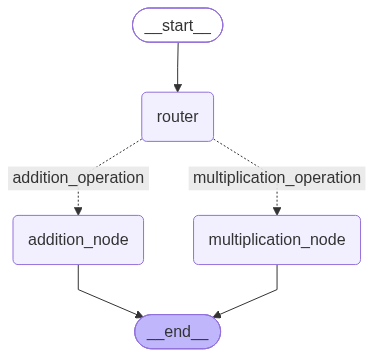

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
#example

from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class agentState(TypedDict):
    number1: int
    number2: int
    operation1: str
    number3: int
    number4: int
    operation2 : str
    result: int

def add_node_first(state: agentState) -> agentState:
    ''' Function that acts as the operation the first add node provides '''
    state["result"] = state["number1"] + state["number2"]
    return state

def subtract_node_first(state: agentState) -> agentState :
    ''' Function that acts as the operation the second node provides'''
    state["result"] = state["number1"] - state["number2"]
    return state

def add_node_second(state: agentState) -> agentState:
    ''' Function that acts as the operation the first add node provides '''
    state["result"] += state["number3"] + state["number4"]
    return state

def subtract_node_second(state: agentState) -> agentState :
    ''' Function that acts as the operation the second node provides'''
    state["result"] += state["number3"] - state["number4"]
    return state

def router1(state: agentState) -> agentState :
    ''' routes the first decision'''
    if state['operation1'] == "+":
        return "Addition_operation_1"
    else :
        return "Subtraction_operation_1"

def router2(state: agentState) -> agentState:
    '''routes the second operation'''
    if state["operation2"] =="+":
        return "Addition_operation_2"
    else:
        return "Subtraction_operation_2"


graph = StateGraph(agentState)
graph.add_node("add_node_first" , add_node_first)
graph.add_node("subtract_node_first", subtract_node_first)
graph.add_node("add_node_second", add_node_second)
graph.add_node("subtract_node_second", subtract_node_second)
graph.add_node("Router1", lambda state: state)
graph.add_node("Router2", lambda state: state)

graph.add_edge(START, "Router1")
graph.add_conditional_edges(
    source= "Router1",
    path= router1,
    path_map= {
        "Addition_operation_1": "add_node_first",
        "Subtraction_operation_1" : "subtract_node_first"
    }
)
graph.add_edge("add_node_first", "Router2")
graph.add_edge("subtract_node_first", "Router2")

graph.add_conditional_edges(
    source= "Router2",
    path= router2,
    path_map= {
        "Addition_operation_2" : "add_node_second", "Subtraction_operation_2" : "subtract_node_second"
    }
)

graph.add_edge("add_node_second",END)
graph.add_edge("subtract_node_second", END)

app = graph.compile()
result= app.invoke({
    "number1": 12,
    "number2": 3,
    "operation1": "-" ,
    "number3": 34 ,
    "number4" : 20,
    "operation2": "+"
})

print(result["result"])

63


#Looping Graph

In [ ]:
import random
from typing import TypedDict, Dict, List
from langgraph.graph import StateGraph, START, END

class agentState(TypedDict):
    name: str
    numbers : List[int]
    counter: int

def greeting_node(state: agentState) -> agentState:
    ''' Function that identifies the node that greets the person '''
    state["name"] = f'Hi there {state["name"]}'
    state["counter"] = 0

    return state

def random_loop_node(state: agentState) -> agentState:
    '''Generates a random number and adds it to the end of the array that is the numbers list'''
    state["numbers"].append(random.randint(0,10))
    state["counter"] +=1
    return state

def should_continue(state: agentState)-> agentState:
    '''Function to decide what to do next'''
    if state["counter"] < 5:
        print("Engineering loop" , state["numbers"])
        return "loop_edge"
    else:
        return "exit_edge"
# one of the way to build a loop
graph = StateGraph(agentState)

graph.add_node("greeting_node", greeting_node)
graph.add_node("random_loop_node", random_loop_node)

graph.add_edge(START, "greeting_node")
graph.add_edge("greeting_node", "random_loop_node")


graph.add_conditional_edges(
    source= "random_loop_node",
    path= should_continue,
    path_map= {
        "loop_edge" : "random_loop_node",
        "exit_edge" : END
    }
)

app = graph.compile()

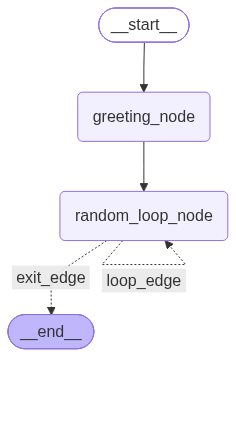

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
results = app.invoke({
    "name" :"Divyanshu",
    "numbers" : [],
    "counter" : -13
})

print(results["numbers"])

Engineering loop [3]
Engineering loop [3, 2]
Engineering loop [3, 2, 10]
Engineering loop [3, 2, 10, 4]
[3, 2, 10, 4, 9]


In [ ]:
#exercise for loop graph

from typing import TypedDict, List,Dict
from langgraph.graph import StateGraph, START, END
import random

class agentState(TypedDict) :
    player_name: str
    target_number: int
    guess: List[int]
    attempts: int
    lower_bound: int
    upper_bound: int
    hint: str

def setup_node(state: agentState) -> agentState:
    ''' Initialized gameplay with a random target value. '''
    state["player_name"] = f"Welcome player {state["player_name"]}!The game has begun! choose a number between 1 and 20 "
    print(state["player_name"])
    #initialise the target number so that the user doesn' enter a random integer himself and set the upper and lower bound accordingly

    state["target_number"] = random.randint(1,20)
    state["lower_bound"] = 1
    state["upper_bound"] = 20
    state["hint"] = "Game started! Trying to guess the number smartly"
    return state

def guess_node(state: agentState) -> agentState:
    '''Generate a random guess based on the previous hint '''
    ''' suppose you guess 9 the hint gets printed out as "The number 9 is too low, so now you will guess say 12 or something else '''

    print(state["hint"])
    possible_guesses = [num for num in range(state["lower_bound"], state["upper_bound"]+1) if num not in state["guess"]]
    if possible_guesses :
        guess = random.choice(possible_guesses)
    else:
        guess = random.randint(state["lower_bound"], state["upper_bound"])

    state["guess"].append(guess)
    state["attempts"] +=1
    print(f"Attempt {state["attempts"]}.: You have guessed {guess}")
    return state

def hint_node(state: agentState) -> agentState :
    '''Here we provide a hint based on the current guess we have made'''
    latest_guess = state["guess"][-1] # retrives the last guess
    target = state["target_number"]

    if target > latest_guess :
        state["hint"] = f"Your guess {latest_guess} is lower than the target!"
        state["lower_bound"] = max(state["lower_bound"], latest_guess + 1 )

    elif target < latest_guess :
        state["hint"] = f"Your guess {latest_guess} is higher than the target!"
        state["upper_bound"] = min(state["upper_bound"], latest_guess - 1)
    else :
        state["hint"] = f"Correct! You have found the number {target}"
    return state

def should_continue(state: agentState) -> agentState :
    '''Determine that if we should make another guess or move to the game over one where we print the state again'''
    latest_guess = state["guess"][-1]
    if latest_guess == state["target_number"] :
        print(state["hint"])
        return "end_edge"

    elif state["attempts"] >=7 :
        print(f'Game over!: Maximum attempts reached! The number was {state["target_number"]}')
        return "end_edge"
    else:
        print(f"Continuing the guesses: {state["attempts"]}/7 attempts used!")
        return "continue_edge"

graph = StateGraph(agentState)

graph.add_node("setup_node" , setup_node)
graph.add_node("guess_node" , guess_node)
graph.add_node("hint_node" , hint_node)

graph.add_edge(START, "setup_node")
graph.add_edge("setup_node", "guess_node")
graph.add_edge("guess_node", "hint_node")

graph.add_conditional_edges(
    source= "hint_node",
    path= should_continue,
    path_map= {
        "end_edge" : END,
        "continue_edge": "guess_node"
    }
)

app = graph.compile()

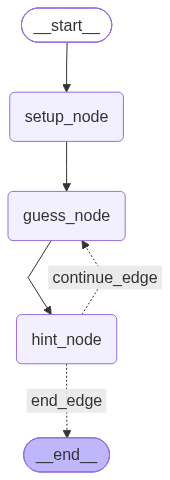

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
# player_name: str
#     target_number: int
#     guess: List[int]
#     attempts: int
#     lower_bound: int
#     upper_bound: int
#     hint: str



result = app.invoke({
    "player_name": "Divyanshu",
    "target_number": 0, # Added missing required field
    "guess": [],
    "attempts": 0,
    "lower_bound": -1 ,
    "upper_bound": 22,
    "hint": ""
})

Welcome player Divyanshu!The game has begun! choose a number between 1 and 20 
Game started! Trying to guess the number smartly
Attempt 1.: You have guessed 16
Continuing the guesses: 1/7 attempts used!
Your guess 16 is higher than the target!
Attempt 2.: You have guessed 8
Continuing the guesses: 2/7 attempts used!
Your guess 8 is higher than the target!
Attempt 3.: You have guessed 7
Continuing the guesses: 3/7 attempts used!
Your guess 7 is higher than the target!
Attempt 4.: You have guessed 1
Continuing the guesses: 4/7 attempts used!
Your guess 1 is lower than the target!
Attempt 5.: You have guessed 6
Continuing the guesses: 5/7 attempts used!
Your guess 6 is higher than the target!
Attempt 6.: You have guessed 4
Continuing the guesses: 6/7 attempts used!
Your guess 4 is higher than the target!
Attempt 7.: You have guessed 2
Correct! You have found the number 2


#Agents : Integrating LLMs into our graphs

In [ ]:
!pip install langchain

In [11]:
!pip install langchain_gemini

In [31]:
# First, install the necessary library for Google Gemini models
!pip install langchain-google-genai

In [32]:
# Import the userdata module from google.colab
from google.colab import userdata

# Load your Google API key from Colab secrets
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

# Set the environment variable for Google API (LangChain will pick this up automatically)
import os
os.environ['GEMINI_API_KEY'] = GEMINI_API_KEY

print("Google API key loaded and set securely.")

Google API key loaded and set securely.


In [ ]:
#Agent: Simple bot

from typing import TypedDict, List
from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI

# HumanMessage and ChatGoogleGenerativeAI are core LangChain classes used to pass user inputs to Gemini chat models

#because we are chatGPT' LLM we are using the ChatOpenAI librabry here iotherwise to run a locally designed

from langgraph.graph import StateGraph, START, END


# from dotenv import load_dotenv
#its just used to store secret stuff like API keys or configuration values, a security purposes->  You do not upload your .env file to public websites like GitHub.

# load_dotenv()

False

In [41]:
class agentState(TypedDict):
    messages : List[HumanMessage]

llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

def processing_node(state: agentState) -> agentState :
    response =  llm.invoke(state["messages"])
    print(f'\n AI: {response.content}')
    return state

graph = StateGraph(agentState)
graph.add_node("AI", processing_node)

graph.add_edge(START, "AI")
graph.add_edge("AI", END)

agent = graph.compile()
print("Agent compiled successfully using ChatGoogleGenerativeAI.")

Agent compiled successfully using ChatGoogleGenerativeAI.


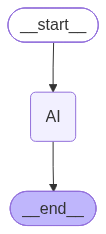

In [42]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

In [43]:
user_input = input("Human: ")
agent.invoke({
    "messages" : [HumanMessage(content= user_input)]
})

Human: Hello can you tell me about clouds? 

 AI: [{'type': 'text', 'text': 'Hello! I’d love to talk about clouds. They are one of the most fascinating and beautiful parts of our everyday weather. \n\nHere is a breakdown of what clouds are, how they form, and the different types.\n\n---\n\n### 1. What is a cloud?\nSimply put, a cloud is a large collection of tiny **water droplets** and/or **ice crystals** floating in the air. \n\nWater is constantly evaporating from the Earth’s surface (oceans, lakes, rivers, plants), turning into an invisible gas called **water vapor**. This warm, invisible vapor rises into the sky.\n\n### 2. How do clouds form?\nCloud formation is a simple three-step process:\n1. **Rising Air:** Warm air rises into the atmosphere because it is lighter than cold air.\n2. **Cooling:** As the air rises, it meets lower pressure and colder temperatures high in the sky. Cold air cannot hold as much water vapor as warm air.\n3. **Condensation:** The invisible water vapor co

{'messages': [HumanMessage(content='Hello can you tell me about clouds? ', additional_kwargs={}, response_metadata={})]}

In [44]:
user_input = input("Human: ")
while user_input.strip()!= "exit":
    agent.invoke({
        "messages" : [HumanMessage(content= user_input)]
    })
    user_input = input("Human: ")


Human: what was the first war Independent India was a part of ?

 AI: [{'type': 'text', 'text': 'The first war that independent India was a part of was the **First Kashmir War (1947–1948)**, also known as the **Indo-Pakistani War of 1947**. \n\nHere are the key details:\n\n* **When:** October 22, 1947 – January 1, 1949 (just a couple of months after India gained independence on August 15, 1947).\n* **Between:** India and Pakistan.\n* **Why:** The conflict erupted over the princely state of Jammu and Kashmir. Tribal militias from Pakistan, backed by the Pakistani military, invaded the region. The Maharaja of Kashmir, Hari Singh, signed the Instrument of Accession, joining India, and subsequently, the Indian military was airlifted into Srinagar to defend the territory.\n* **Outcome:** The war ended with a United Nations-brokered ceasefire and the establishment of the **Line of Control (LoC)**, leaving Kashmir divided between the two nations—a dispute that continues to this day.', 'extras

#Agent 2: Giving the AI the memory it needed

In [1]:
!pip install langchain_google_genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.4/262.4 kB 25.8 MB/s eta 0:00:00
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.49.0
    Uninstalling google-auth-2.49.0:
      Successfully uninstalled google-auth-2.49.0
  Attempting uninstall: google-genai
    Found existing installation: google-genai 2.12.1
    Uninstalling google-genai-2.12.1:
      Successfully uninstalled google-genai-2.12.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.0 which is incompatible.


In [2]:
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

# Set the environment variable for Google API (LangChain will pick this up automatically)
import os
os.environ['GEMINI_API_KEY'] = GEMINI_API_KEY

In [3]:
from typing import TypedDict, List, Union
from langchain_core.messages import HumanMessage, AIMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END


class agentState(TypedDict) :
    # human_messages : List[HumanMessage]
    # ai_message : List[AIMessage] ---- > A naive approach
    messages : List[Union[HumanMessage, AIMessage]]

llm = ChatGoogleGenerativeAI(model= "gemini-3.5-flash-lite")
def process(state: agentState) -> agentState :
    '''This node will bring the response of the client or user query by prompting the llm we have provided here'''

    response = llm.invoke(state["messages"])

    state["messages"].append(AIMessage(content= response.content))
    # what happened in the previous response is that when we get a response, we convert it into an AIMessage Data type and then append it to the messages of the state
    print(f'\n AI: {response.content}')

    return state

graph = StateGraph(agentState)

graph.add_node("ai", process)

graph.add_edge(START, "ai")
graph.add_edge("ai", END)

agent = graph.compile()

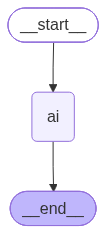

In [4]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

In [5]:
conversation_history= []
user_input = input("Human : ")
while user_input.strip() != "Exit" :
    conversation_history.append(HumanMessage(user_input))
    result = agent.invoke({
        "messages" : conversation_history
    })
    print(result["messages"])
    conversation_history = result["messages"]
    user_input = input("Human : ")

Human : Hi there Gemini! What do you know about the mountain ranges of india 



 AI: [{'type': 'text', 'text': 'Hello! I’d love to talk about the mountain ranges of India. They are some of the most majestic, ecologically diverse, and historically significant in the world. India’s topography is dramatically defined by these mountains, which range from the towering, snow-capped Himalayas in the north to the ancient, weathered hills of the peninsula.\n\nHere is a breakdown of the major mountain ranges of India, grouped by region:\n\n---\n\n### 1. The Himalayan System (The Northern Crown)\nThe Himalayas (meaning "Abode of Snow") are the highest and youngest fold mountains in the world. They formed through the collision of the Indian Plate and the Eurasian Plate. In India, the Himalayas span several states (like Jammu & Kashmir, Himachal Pradesh, Uttarakhand, Sikkim, and Arunachal Pradesh) and are generally divided into three parallel ranges:\n\n*   **Himadri (Greater Himalayas):** The northernmost and highest range. It contains the world\'s highest peaks outside of N

KeyboardInterrupt: Interrupted by user